# Notebook 05 - Random Forest Training

**Kelompok 06 - Kecerdasan Buatan 02**

| NPM | Nama |
|-----|------|
| 2306242395 | Calvin Wirathama Katoroy |
| 2306220532 | Syahmi Hamdani |
| 2306220323 | Christover Angelo |
| 2306221024 | Matthew Immanuel |

**Tujuan:** Melatih Random Forest sebagai baseline 2 pada flat feature vectors (tanpa sequence windowing). 6 eksperimen hyperparameter: n_estimators, max_depth, min_samples_split. Tidak memerlukan GPU.

In [21]:
import subprocess, os
from pathlib import Path

REPO_URL  = 'https://github.com/calvinkatoroy/tugas-akhir-ai-kel-06.git'
REPO_NAME = 'tugas-akhir-ai-kel-06'

cwd = Path.cwd()

if (cwd / '../src').resolve().exists():
    result = subprocess.run(['git', '-C', str((cwd / '..').resolve()), 'pull'],
                            capture_output=True, text=True)
    print(result.stdout.strip() or 'Already up to date.')

elif (cwd / 'src').exists():
    result = subprocess.run(['git', 'pull'], capture_output=True, text=True)
    print(result.stdout.strip() or 'Already up to date.')
    os.chdir('notebooks')

else:
    repo_path = cwd / REPO_NAME
    if not repo_path.exists():
        print(f'Cloning {REPO_URL} ...')
        subprocess.run(['git', 'clone', REPO_URL], check=True)
    else:
        print('Repo found, pulling latest...')
        subprocess.run(['git', '-C', str(repo_path), 'pull'], capture_output=True)
    os.chdir(repo_path / 'notebooks')

print(f'Working dir: {Path.cwd()}')

Updating 679890f..761e455
Fast-forward
 notebooks/05_rf_training.ipynb | 794 +++++++++++++++++++++++++++++++----------
 1 file changed, 611 insertions(+), 183 deletions(-)
Working dir: /content/tugas-akhir-ai-kel-06/notebooks


In [22]:
import sys
sys.path.insert(0, '..')

import random, copy
import numpy as np
import yaml
from pathlib import Path

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
def safe_log_experiment(record, csv_path):
    import os, pandas as pd
    from pathlib import Path
    path = Path(csv_path)
    if path.exists():
        try:
            pd.read_csv(path)
        except Exception:
            print(f'WARNING: corrupt CSV at {path}, resetting.')
            os.remove(path)
    from src.utils import log_experiment
    log_experiment(record, csv_path=csv_path)


In [23]:
from pathlib import Path

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    DRIVE_ROOT = Path("/content/drive/MyDrive/tugas-akhir-ai")
    SPLITS_DIR = DRIVE_ROOT / "splits"
else:
    import yaml
    with open("../config.yaml") as f:
        _cfg = yaml.safe_load(f)
    DRIVE_ROOT = Path(_cfg["data"]["drive_root"])
    SPLITS_DIR = Path(_cfg["data"]["splits_drive"])

print(f"DRIVE_ROOT: {DRIVE_ROOT}")
print(f"SPLITS_DIR: {SPLITS_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DRIVE_ROOT: /content/drive/MyDrive/tugas-akhir-ai
SPLITS_DIR: /content/drive/MyDrive/tugas-akhir-ai/splits


In [24]:
with open("../config.yaml") as f:
    cfg = yaml.safe_load(f)

# RF uses flat (non-windowed) splits
X_train = np.load(SPLITS_DIR / "X_train.npy")
y_train = np.load(SPLITS_DIR / "y_train.npy")
X_val   = np.load(SPLITS_DIR / "X_val.npy")
y_val   = np.load(SPLITS_DIR / "y_val.npy")
X_test  = np.load(SPLITS_DIR / "X_test.npy")
y_test  = np.load(SPLITS_DIR / "y_test.npy")

print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

Train: (301959, 16)  Val: (64705, 16)  Test: (64707, 16)


## Baseline run (config defaults)

In [25]:
import os, shutil
_ckpt_local = '../results/checkpoints/best_rf.pkl'
_ckpt_drive = str(DRIVE_ROOT / 'best_rf.pkl')

if not os.path.exists(_ckpt_local) and os.path.exists(_ckpt_drive):
    os.makedirs('../results/checkpoints', exist_ok=True)
    shutil.copy(_ckpt_drive, _ckpt_local)
    print('Restored best_rf.pkl from Drive')

if os.path.exists(_ckpt_local):
    print('RF checkpoint found - loading instead of retraining.')
    from src.models.rf_model import load_rf
    rf = load_rf(_ckpt_local)
else:
    from src.models.rf_model import build_rf, train_rf, save_rf
    from src.utils import log_experiment
    from sklearn.metrics import f1_score

    rf = build_rf(cfg)
    print(rf)
    rf = train_rf(rf, X_train, y_train)

    val_pred = rf.predict(X_val)
    val_f1   = f1_score(y_val, val_pred, average="binary", pos_label=1)
    print(f"Val F1: {val_f1:.4f}")

    save_rf(rf, "../results/checkpoints/best_rf.pkl")

    log_experiment({
        "exp_id": "rf_01_baseline",
        "model": "RandomForest",
        "best_val_f1": round(val_f1, 4),
        "notes": f"baseline n_est={cfg["random_forest"]["n_estimators"]} depth={cfg["random_forest"]["max_depth"]}",
    }, csv_path=str(DRIVE_ROOT / "metrics_summary.csv"))

RF checkpoint found - loading instead of retraining.


## Hyperparameter Experiments

In [26]:
def run_rf_experiment(exp_id, overrides, notes=""):
    import copy
    from src.models.rf_model import build_rf, train_rf
    from sklearn.metrics import f1_score

    exp_cfg = copy.deepcopy(cfg)
    exp_cfg["random_forest"].update(overrides)

    m = build_rf(exp_cfg)
    m = train_rf(m, X_train, y_train)
    val_pred = m.predict(X_val)
    best_f1  = round(f1_score(y_val, val_pred, average="binary", pos_label=1), 4)

    safe_log_experiment({
        "exp_id": exp_id,
        "model": "RandomForest",
        "best_val_f1": best_f1,
        "notes": notes,
    }, csv_path=str(DRIVE_ROOT / "metrics_summary.csv"))
    print(f"[{exp_id}] val_F1={best_f1}")
    return m, best_f1


In [27]:
_, f1_02 = run_rf_experiment('rf_02_trees50',   {'n_estimators': 50},          'n_estimators=50')

[rf_02_trees50] val_F1=0.999


In [28]:
_, f1_03 = run_rf_experiment('rf_03_trees200',  {'n_estimators': 200},         'n_estimators=200')

[rf_03_trees200] val_F1=0.999


In [29]:
_, f1_04 = run_rf_experiment('rf_04_depth10',   {'max_depth': 10},             'max_depth=10')

[rf_04_depth10] val_F1=0.998


In [30]:
_, f1_05 = run_rf_experiment('rf_05_depth20',   {'max_depth': 20},             'max_depth=20')

[rf_05_depth20] val_F1=0.999


In [31]:
_, f1_06 = run_rf_experiment('rf_06_minsplit5', {'min_samples_split': 5},      'min_samples_split=5')

[rf_06_minsplit5] val_F1=0.9989


## Feature Importance

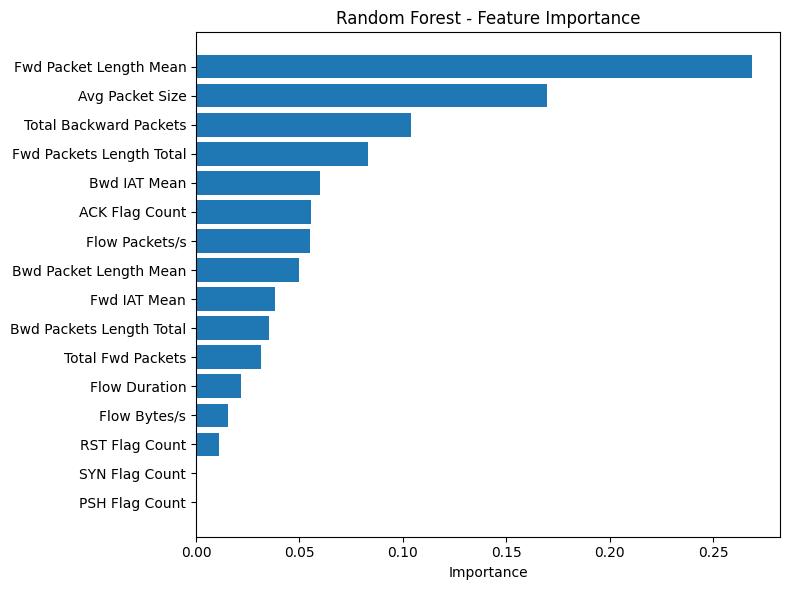

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

features = cfg['features']
importances = rf.feature_importances_
fi_df = pd.DataFrame({'feature': features, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(fi_df['feature'], fi_df['importance'])
ax.set_xlabel('Importance')
ax.set_title('Random Forest - Feature Importance')
plt.tight_layout()
plt.savefig('../results/figures/rf_feature_importance.png', dpi=150)
plt.show()

## Final Evaluation on Test Set

             exp_id  best_val_f1                          notes
14   rf_01_baseline       0.9990  baseline n_est=100 depth=None
15    rf_02_trees50       0.9990                n_estimators=50
16   rf_03_trees200       0.9990               n_estimators=200
17    rf_04_depth10       0.9980                   max_depth=10
18    rf_05_depth20       0.9990                   max_depth=20
19  rf_06_minsplit5       0.9989            min_samples_split=5
20              NaN          NaN                            NaN
21    rf_02_trees50       0.9990                n_estimators=50
22   rf_03_trees200       0.9990               n_estimators=200
23    rf_04_depth10       0.9980                   max_depth=10
24    rf_05_depth20       0.9990                   max_depth=20
25  rf_06_minsplit5       0.9989            min_samples_split=5

=== RandomForest  -  Classification Report ===
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00     14675
        ddo

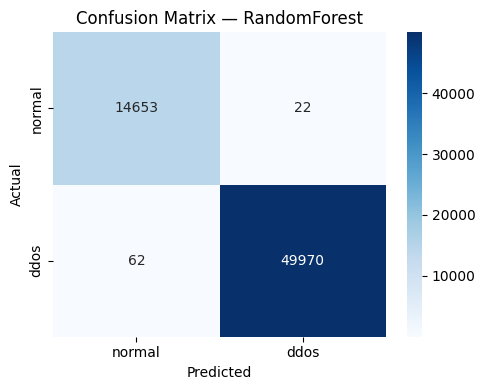

  FPR=0.0015  ROC-AUC=0.9998


In [33]:
import pandas as pd
from src.models.rf_model import load_rf
from src.evaluate import evaluate_rf_model

# Print experiment table
results = pd.read_csv(str(DRIVE_ROOT / "metrics_summary.csv"))
rf_results = results[results['model'] == 'RandomForest']
avail = [c for c in ['exp_id', 'n_estimators', 'max_depth', 'best_val_f1', 'notes'] if c in rf_results.columns]
print(rf_results[avail])

# Evaluate best checkpoint on test set
best_rf = load_rf('../results/checkpoints/best_rf.pkl')
y_pred_rf, y_prob_rf = evaluate_rf_model(
    best_rf, X_test, y_test,
    figures_dir='../results/figures',
    csv_path=str(DRIVE_ROOT / "metrics_summary.csv"),
)

np.save('../results/rf_y_prob.npy', y_prob_rf)
np.save('../results/y_test_flat.npy', y_test)

In [34]:
# Save best checkpoint to Drive so it persists across sessions
import shutil
shutil.copy("../results/checkpoints/best_rf.pkl", str(DRIVE_ROOT / "best_rf.pkl"))
np.save(str(DRIVE_ROOT / "rf_y_prob.npy"), y_prob_rf)
np.save(str(DRIVE_ROOT / "y_test_flat.npy"), y_test)
print(f"Checkpoint + probs saved to Drive: {DRIVE_ROOT}")

Checkpoint + probs saved to Drive: /content/drive/MyDrive/tugas-akhir-ai
